In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import seaborn as sns

from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from scipy.stats import pearsonr


image_dir="/home/ricbec/projects/binding-affinity/DAT675-Project/data/images"

In [38]:
#file_prefixes=[ "original_fixed", "binary" "reduced-gaussian-4", "reduced-gaussian-8", "distance-binned",   ]
file_prefixes=[ "original_fixed", "binary", "distance-binned",   ]
file_prefixes=[]
experiment_names = {'author_check': 'baseline',
                    "distance-binned": "distance-binned", 
                    "binary": "binary", 
                    "reduced-gaussian-4": "4 Gaussians", 
                    "reduced-gaussian-8": "8 Gaussians", 
                    "original_fixed": "baseline w/o leakage"
                   }

cutoffs = [2, 3, 4,5,6,7, 50]
pred_cols = ["preds_0","preds_1","preds_2","preds_3","preds_4"]
datasets = [
    "0ligandbias",
    "casf2016",
    "fep",
    "oodtest"
]

for cutoff in cutoffs:
    prefix = f'cutoff{cutoff}'
    file_prefixes.append(prefix)
    experiment_names[prefix] = f"cutoff {cutoff} Å"

search_dirs = [
    Path("/home/ricbec/projects/binding-affinity/DAT675-Project/data/topology"),       
    Path("/home/ricbec/projects/binding-affinity/DAT675-Project/data/encodings")
]



def find_file(file_prefix, dataset):
    """
    Search for a CSV file matching the prefix and dataset in all search_dirs.
    Returns the first match found.
    """
    for search_dir in search_dirs:
        # Look recursively for CSV files
        for path in search_dir.rglob("*.csv"):
            # Convert to lowercase to avoid case issues
            fname = path.name.lower()
            if file_prefix.lower() in fname and dataset.lower() in fname:
                return path
    raise FileNotFoundError(f"No file found for prefix '{file_prefix}' and dataset '{dataset}'")


In [39]:
# Use seaborn theme
sns.set_theme(style="whitegrid")

# Default color palette
sns.set_palette("viridis")

# Matplotlib rcParams
mpl.rcParams.update({

    # Figure settings
    "figure.figsize": (7, 5),
    "figure.dpi": 120,
    "savefig.dpi": 300,

    # Font sizes
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,

    # Grid settings
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    # Axis styling
    "axes.spines.top": True,
    "axes.spines.right": True,

    # Layout
    "figure.autolayout": True,
})



print("Global plotting style configured.")

Global plotting style configured.


<>:133: SyntaxWarning: invalid escape sequence '\p'
<>:133: SyntaxWarning: invalid escape sequence '\p'
<>:133: SyntaxWarning: invalid escape sequence '\p'
<>:133: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1444436/1470365400.py:133: SyntaxWarning: invalid escape sequence '\p'
  metrics = f"PCC={row['pcc_mean']:.2f}$\pm$ {row['pcc_std']:.2f}, τ={row['tau_mean']:.2f}$\pm$ {row['tau_std']:.2f}"
/tmp/ipykernel_1444436/1470365400.py:133: SyntaxWarning: invalid escape sequence '\p'
  metrics = f"PCC={row['pcc_mean']:.2f}$\pm$ {row['pcc_std']:.2f}, τ={row['tau_mean']:.2f}$\pm$ {row['tau_std']:.2f}"


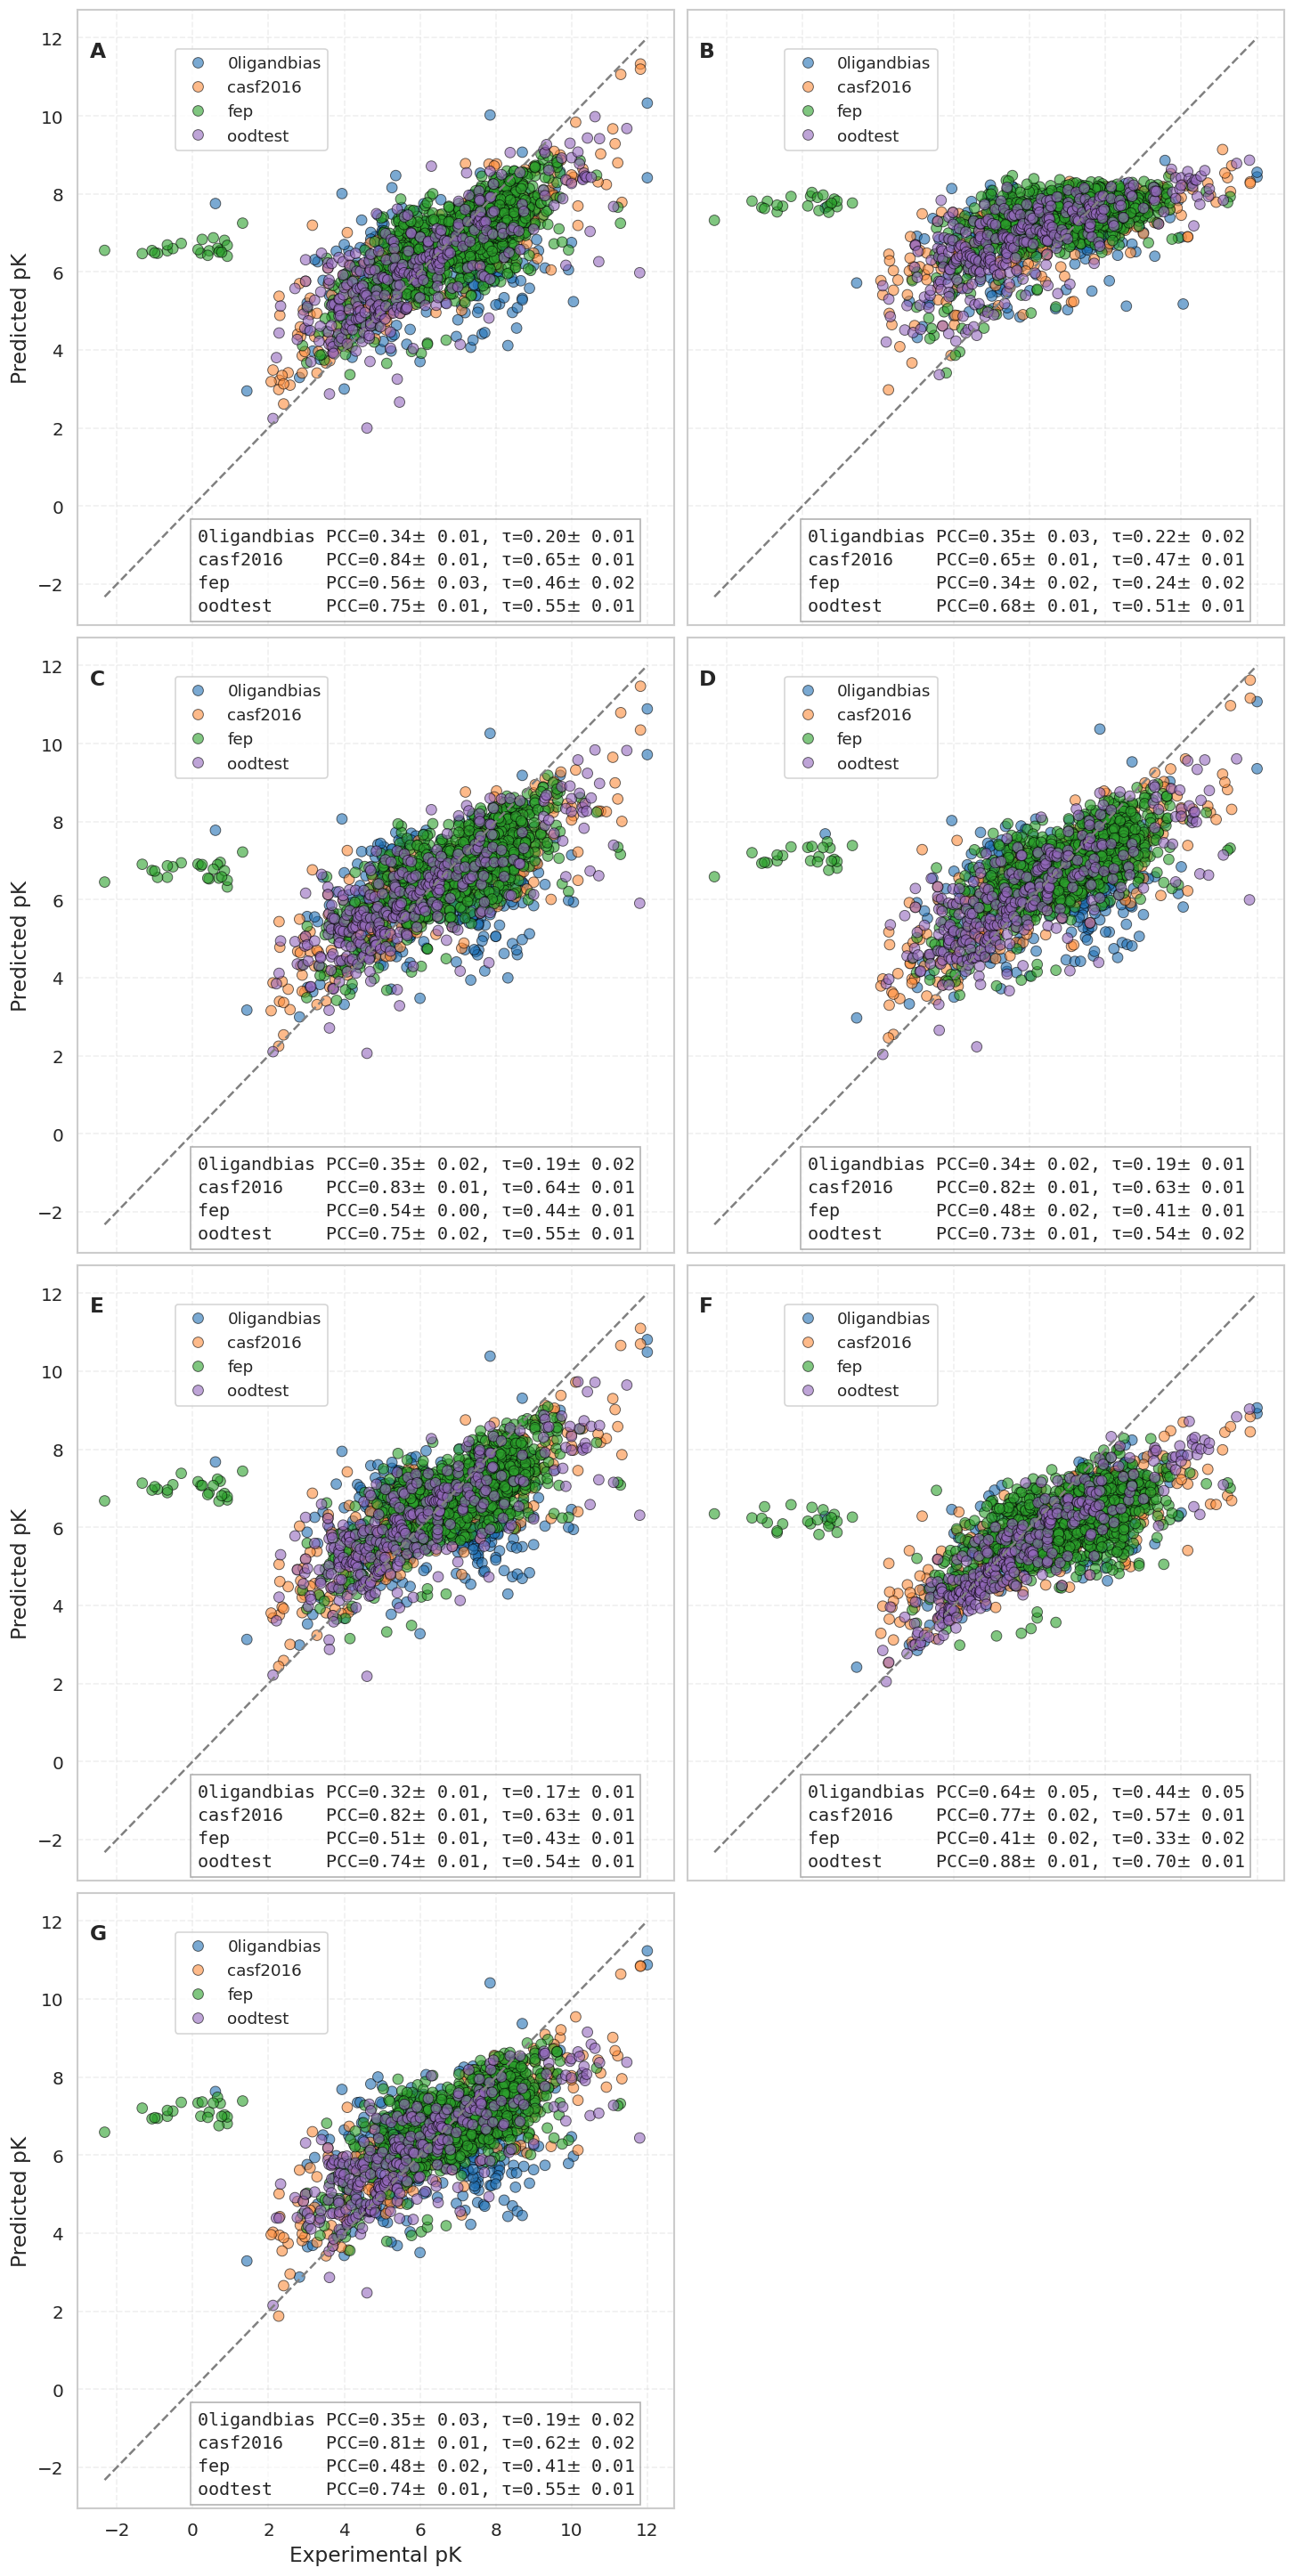

In [40]:
import string
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr, kendalltau

# -----------------------
# Collect all metrics for plotting
# -----------------------

all_metrics = []
all_dfs = []

for file_prefix in file_prefixes:
    dfs = []
    for dataset in datasets:
        file = find_file(file_prefix, dataset)
        df = pd.read_csv(file)
        df["dataset"] = dataset
        dfs.append(df)
    df_all = pd.concat(dfs, ignore_index=True)
    all_dfs.append((file_prefix, df_all))

    # Compute metrics per dataset
    metrics = []
    for dataset in datasets:
        df = df_all[df_all["dataset"] == dataset]
        taus, pccs = [], []

        for col in pred_cols:
            y_true = df["pK"]
            y_pred = df[col]
            pcc, _ = pearsonr(y_true, y_pred)
            tau, _ = kendalltau(y_true, y_pred)
            taus.append(tau)
            pccs.append(pcc)

        metrics.append({
            "dataset": dataset,
            "tau_mean": np.mean(taus),
            "tau_std": np.std(taus),
            "pcc_mean": np.mean(pccs),
            "pcc_std": np.std(pccs)
        })
    metrics_df = pd.DataFrame(metrics)
    all_metrics.append((file_prefix, metrics_df))

# -----------------------
# Layout
# -----------------------
n_experiments = len(file_prefixes)
n_cols = 2
n_rows = math.ceil(n_experiments / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows), constrained_layout=True)
axes = axes.flatten()  # Flatten in case n_rows > 1

alphabet = list(string.ascii_uppercase)

# -----------------------
# Plot each experiment
# -----------------------
for i, (file_prefix, df_all) in enumerate(all_dfs):
    ax = axes[i]

    row_idx = i // n_cols
    col_idx = i % n_cols

    # Palette for datasets
    palette_dict = {
        "0ligandbias": "#2171B5",  # Blue
        "casf2016": "#FD8D3C",     # Orange
        "fep": "#2CA02C",           # Green
        "oodtest": "#9467BD",       # Purple
    }

    # Scatter plot
    sns.scatterplot(
        data=df_all,
        x="pK",
        y="preds",
        hue="dataset",
        palette=palette_dict,
        s=50,
        edgecolor="black",
        alpha=0.6,
        ax=ax
    )

    min_val = min(df_all["pK"].min(), df_all["preds"].min())
    max_val = max(df_all["pK"].max(), df_all["preds"].max())
    ax.plot([min_val, max_val], [min_val, max_val], "--", color="gray")
    ax.legend(bbox_to_anchor=(.15, 0.95))
    
    # Remove title
    ax.set_title("")

    # Axis labels: only bottom row and left column
    if row_idx == n_rows - 1:
        ax.set_xlabel("Experimental pK")
        ax.tick_params(axis='x', labelbottom=True)
    else:
        ax.set_xlabel("")
        ax.tick_params(axis='x', labelbottom=False)

    if col_idx == 0:
        ax.set_ylabel("Predicted pK")
        ax.tick_params(axis='y', labelleft=True)
    else:
        ax.set_ylabel("")
        ax.tick_params(axis='y', labelleft=False)

    # Alphabetic panel label
    ax.text(
        0.02, 0.95, f"{alphabet[i]}",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        verticalalignment='top'
    )

    # Add Kendall tau & PCC per dataset
    metrics_df = [m for fp, m in all_metrics if fp == file_prefix][0]
    metrics_lines = []
    # Find max length of dataset names for padding
    max_name_len = max(metrics_df["dataset"].apply(len))

    for _, row in metrics_df.iterrows():
        name = row["dataset"]
        metrics = f"PCC={row['pcc_mean']:.2f}$\pm$ {row['pcc_std']:.2f}, τ={row['tau_mean']:.2f}$\pm$ {row['tau_std']:.2f}"
        line = f"{name.ljust(max_name_len)} {metrics.rjust(5)}"
        metrics_lines.append(line)
    metrics_text = "\n".join(metrics_lines)

    ax.text(
        0.20, 0.16, metrics_text,
        transform=ax.transAxes,
        verticalalignment='top',
        fontfamily="monospace",
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray')
    )

# Turn off unused axes if n_experiments is odd
for j in range(n_experiments, len(axes)):
    axes[j].axis("off")


#plt.tight_layout()
plt.savefig(f"{image_dir}/all_correlation_plots_tight_labeled.png")
plt.show()

baseline w/o leakage & $0.34 \pm 0.02$/$0.19 \pm 0.01$ & $0.82 \pm 0.01$/$0.63 \pm 0.01$ & $0.52 \pm 0.02$/$0.44 \pm 0.01$ & $0.73 \pm 0.01$/$0.54 \pm 0.02$ \\
binary & $0.34 \pm 0.02$/$0.19 \pm 0.01$ & $0.82 \pm 0.01$/$0.63 \pm 0.01$ & $0.52 \pm 0.02$/$0.44 \pm 0.01$ & $0.73 \pm 0.01$/$0.54 \pm 0.02$ \\
distance-binned & $0.34 \pm 0.02$/$0.19 \pm 0.01$ & $0.82 \pm 0.01$/$0.63 \pm 0.01$ & $0.52 \pm 0.02$/$0.44 \pm 0.01$ & $0.73 \pm 0.01$/$0.54 \pm 0.02$ \\
cutoff 5 Å & $0.34 \pm 0.02$/$0.19 \pm 0.01$ & $0.82 \pm 0.01$/$0.63 \pm 0.01$ & $0.52 \pm 0.02$/$0.44 \pm 0.01$ & $0.73 \pm 0.01$/$0.54 \pm 0.02$ \\


In [5]:
cutoff_metrics = []

for cutoff in cutoffs:

    print(f"Processing cutoff {cutoff}")

    dfs = []

    for dataset in datasets:
        file_prefix = f'cutoff{cutoff}'
        file = find_file(file_prefix, dataset)

        df = pd.read_csv(file)
        df["dataset"] = dataset

        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)

    # -----------------------
    # Metrics per dataset
    # -----------------------

    for dataset in datasets:

        df = df_all[df_all["dataset"] == dataset]

        rmses = []
        r2s = []
        taus = []
        pccs = []

        for col in pred_cols:

            y_true = df["pK"]
            y_pred = df[col]

            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            r2 = r2_score(y_true, y_pred)
            pcc, _ = pearsonr(y_true, y_pred)
            tau, _ = kendalltau(y_true, y_pred)

            rmses.append(rmse)
            r2s.append(r2)
            taus.append(tau)
            pccs.append(pcc)

        cutoff_metrics.append({
            "cutoff": cutoff,
            "dataset": dataset,
            "RMSE_mean": np.mean(rmses),
            "RMSE_std": np.std(rmses),
            "pcc_mean": np.mean(pccs),
            "pcc_std": np.std(pccs),
            "tau_mean": np.mean(taus),
            "tau_std": np.std(taus),
        })

metrics_vs_cutoff = pd.DataFrame(cutoff_metrics)

plt.figure(figsize=(9,6))

palette_dict = {
    "0ligandbias": "#2171B5",
    "casf2016": "#FD8D3C",
    "fep": "#2CA02C",
    "oodtest": "#9467BD",
}

markers = {
    "RMSE": "o",
    "PCC": "s",
    "tau": "^"
}

for dataset in datasets:

    df = metrics_vs_cutoff[metrics_vs_cutoff["dataset"] == dataset]

    color = palette_dict[dataset]

    plt.errorbar(
        df["cutoff"],
        df["RMSE_mean"],
        yerr=df["RMSE_std"],
        marker=markers["RMSE"],
        color=color,
        label=f"{dataset} RMSE"
    )

    plt.errorbar(
        df["cutoff"],
        df["pcc_mean"],
        yerr=df["pcc_std"],
        marker=markers["PCC"],
        color=color,
        linestyle="--",
        label=f"{dataset} PCC"
    )

    plt.errorbar(
        df["cutoff"],
        df["tau_mean"],
        yerr=df["tau_std"],
        marker=markers["tau"],
        color=color,
        linestyle=":",
        label=rf"{dataset} $\tau$"
    )

plt.xlabel("Cutoff Radius [Å]")
plt.ylabel("Metric value")

#plt.title("Model performance vs cutoff")

# Dataset legend (colours)
dataset_handles = [
    Line2D([0], [0], color=palette_dict[d], lw=2, label=d)
    for d in datasets
]

# Metric legend (symbols)
metric_handles = [
    Line2D([0], [0], color="darkgray", marker="o", linestyle="-", markersize=8, label="RMSE"),
    Line2D([0], [0], color="darkgray", marker="s", linestyle="--", markersize=8, label="PCC"),
    Line2D([0], [0], color="darkgray", marker="^", linestyle=":", markersize=8, label=r"$\tau$")
]

ax = plt.gca()

# Dataset legend (left side of top center)
legend1 = ax.legend(
    handles=dataset_handles,
    title="Dataset",
    loc="upper center",
    bbox_to_anchor=(0.2, 1.20),
    ncol=2,
    frameon=False
)

# Metric legend (right side of top center)
legend2 = ax.legend(
    handles=metric_handles,
    title="Metric",
    loc="upper center",
    bbox_to_anchor=(0.7, 1.20),
    ncol=len(metric_handles),
    frameon=False
)

ax.add_artist(legend1)

plt.tight_layout()

plt.savefig(f"{image_dir}/cutoff_curve.jpg")
plt.show()


Processing cutoff 4


NameError: name 'find_file' is not defined

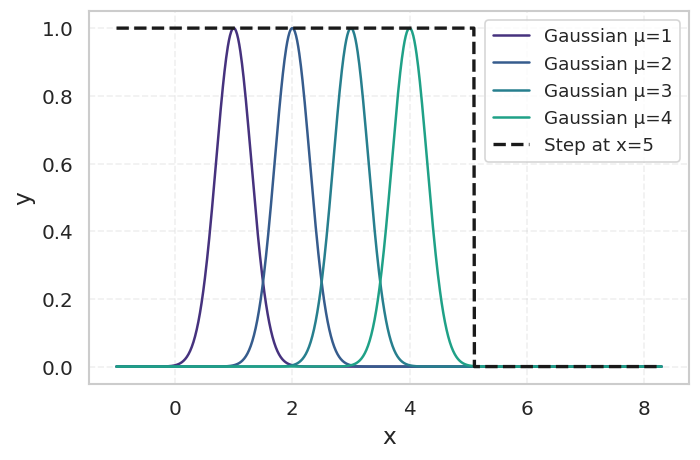

In [6]:
# Parameters
centers = [1, 2, 3, 4]
sigma = 0.3          # width (standard deviation), adjust as you like
x = np.linspace(-1, 8.3, 1000)

# Gaussian function
def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Plot Gaussians
plt.figure(figsize=(6, 4))
for mu in centers:
    y = gaussian(x, mu, sigma)
    plt.plot(x, y, label=f'Gaussian μ={mu}')

# Step function: 1 for x < 5, 0 for x ≥ 5
step = np.where(x < 5.1, 1.0, 0.0)
plt.plot(x, step, 'k--', linewidth=2, label='Step at x=5')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gaussian_demonstration.png")
plt.show()

In [7]:
# -------------------------
# Load datasets
# -------------------------

bindingdb = pd.read_csv("bindingdb_processed.csv")
bindingnet = pd.read_csv("bindingnet_processed.csv")
pdbbind = pd.read_csv("pdbbind_processed.csv")

# -------------------------
# Normalize identifiers
# -------------------------

bindingdb_ids = (
    bindingdb["pdb_file"]
    .str.replace(".pdb", "", regex=False)
    .str.lower()
)

bindingnet_ids = (
    bindingnet["pdb"]
    .str.lower()
)

pdbbind_ids = (
    pdbbind["PDB_code"]
    .str.lower()
)

# Convert to sets
set_bindingdb = set(bindingdb_ids.dropna())
set_bindingnet = set(bindingnet_ids.dropna())
set_pdbbind = set(pdbbind_ids.dropna())

# -------------------------
# Compute overlaps
# -------------------------

overlap_db_net = set_bindingdb & set_bindingnet
overlap_db_pdbbind = set_bindingdb & set_pdbbind
overlap_net_pdbbind = set_bindingnet & set_pdbbind

overlap_all = set_bindingdb & set_bindingnet & set_pdbbind

# -------------------------
# Print results
# -------------------------

print("Dataset sizes:")
print(f"BindingDB:   {len(set_bindingdb)} proteins")
print(f"BindingNet:  {len(set_bindingnet)} proteins")
print(f"PDBBind:     {len(set_pdbbind)} proteins")

print("\nPairwise overlaps:")
print(f"BindingDB ∩ BindingNet:  {len(overlap_db_net)}")
print(f"BindingDB ∩ PDBBind:     {len(overlap_db_pdbbind)}")
print(f"BindingNet ∩ PDBBind:    {len(overlap_net_pdbbind)}")

print("\nThree-way overlap:")
print(f"BindingDB ∩ BindingNet ∩ PDBBind: {len(overlap_all)}")

Dataset sizes:
BindingDB:   1311 proteins
BindingNet:  5903 proteins
PDBBind:     19308 proteins

Pairwise overlaps:
BindingDB ∩ BindingNet:  653
BindingDB ∩ PDBBind:     956
BindingNet ∩ PDBBind:    5900

Three-way overlap:
BindingDB ∩ BindingNet ∩ PDBBind: 653


count    1322.000000
mean        6.673222
std         5.247892
min         1.000000
25%         1.000000
50%         5.000000
75%        12.000000
max        19.000000
dtype: float64


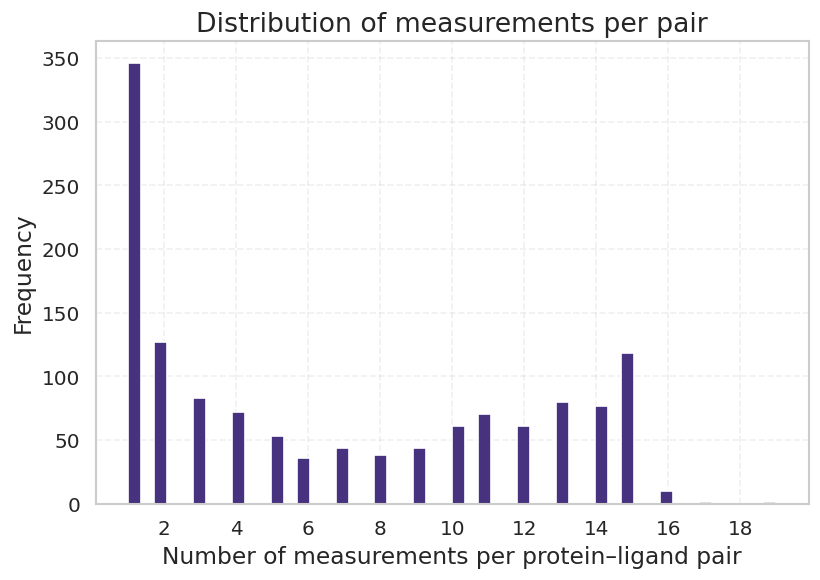

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

bindingdb = pd.read_csv("bindingdb_processed.csv")

# Count number of measurements per protein–ligand pair
pair_counts = bindingdb.groupby("folder").size()

print(pair_counts.describe())

# Plot distribution (histogram)
plt.figure()
pair_counts.hist(bins=50)
plt.xlabel("Number of measurements per protein–ligand pair")
plt.ylabel("Frequency")
plt.xticks([2,4,6,8,10,12,14,16,18])
plt.title("Distribution of measurements per pair")
plt.savefig(f"{image_dir}/measurements_per_pair.png")
plt.show()

Pairs with only one measurement: 89678


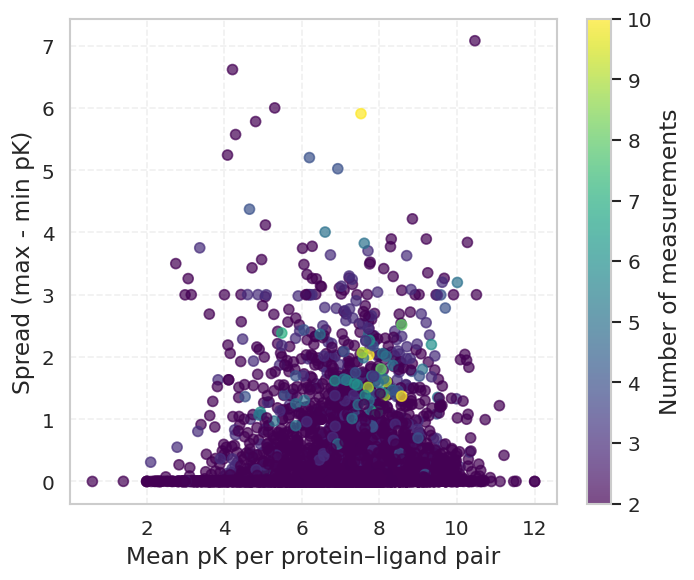

In [9]:
# -------------------------
# Load unified dataset
# -------------------------
df = pd.read_csv("unified_data.csv")

# Make sure we drop rows missing pdb_id or smiles
df = df.dropna(subset=["pdb_id", "smiles"])

# -------------------------
# Define protein–ligand pair
# -------------------------
df["pair"] = df["pdb_id"] + "_" + df["smiles"]

# -------------------------
# Aggregate statistics per pair
# -------------------------
pair_stats = df.groupby("pair")["pK"].agg(["min", "max", "mean"])

# Compute spread (difference between max and min)
pair_stats["spread"] = pair_stats["max"] - pair_stats["min"]

# Count number of measurements per pair
pair_stats["count"] = df.groupby("pair").size()

# -------------------------
# Filter for pairs with multiple measurements
# -------------------------
num_single = len(pair_stats[pair_stats["count"] == 1])
print(f"Pairs with only one measurement: {num_single}")

# Keep only pairs with >1 measurement
pair_stats_multi = pair_stats[pair_stats["count"] > 1]

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(6,5))
sc = plt.scatter(
    pair_stats_multi["mean"],
    pair_stats_multi["spread"],
    c=pair_stats_multi["count"],
    cmap="viridis",
    alpha=0.7
)
plt.colorbar(sc, label="Number of measurements")

plt.xlabel("Mean pK per protein–ligand pair")
plt.ylabel("Spread (max - min pK)")
#plt.title("Measurement variability vs binding strength")

plt.tight_layout()
plt.savefig(f"{image_dir}/multi_measurement_deviation.png")
plt.show()

/home/ricbec/software/miniconda3/lib/python3.12/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/ricbec/software/miniconda3/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewid

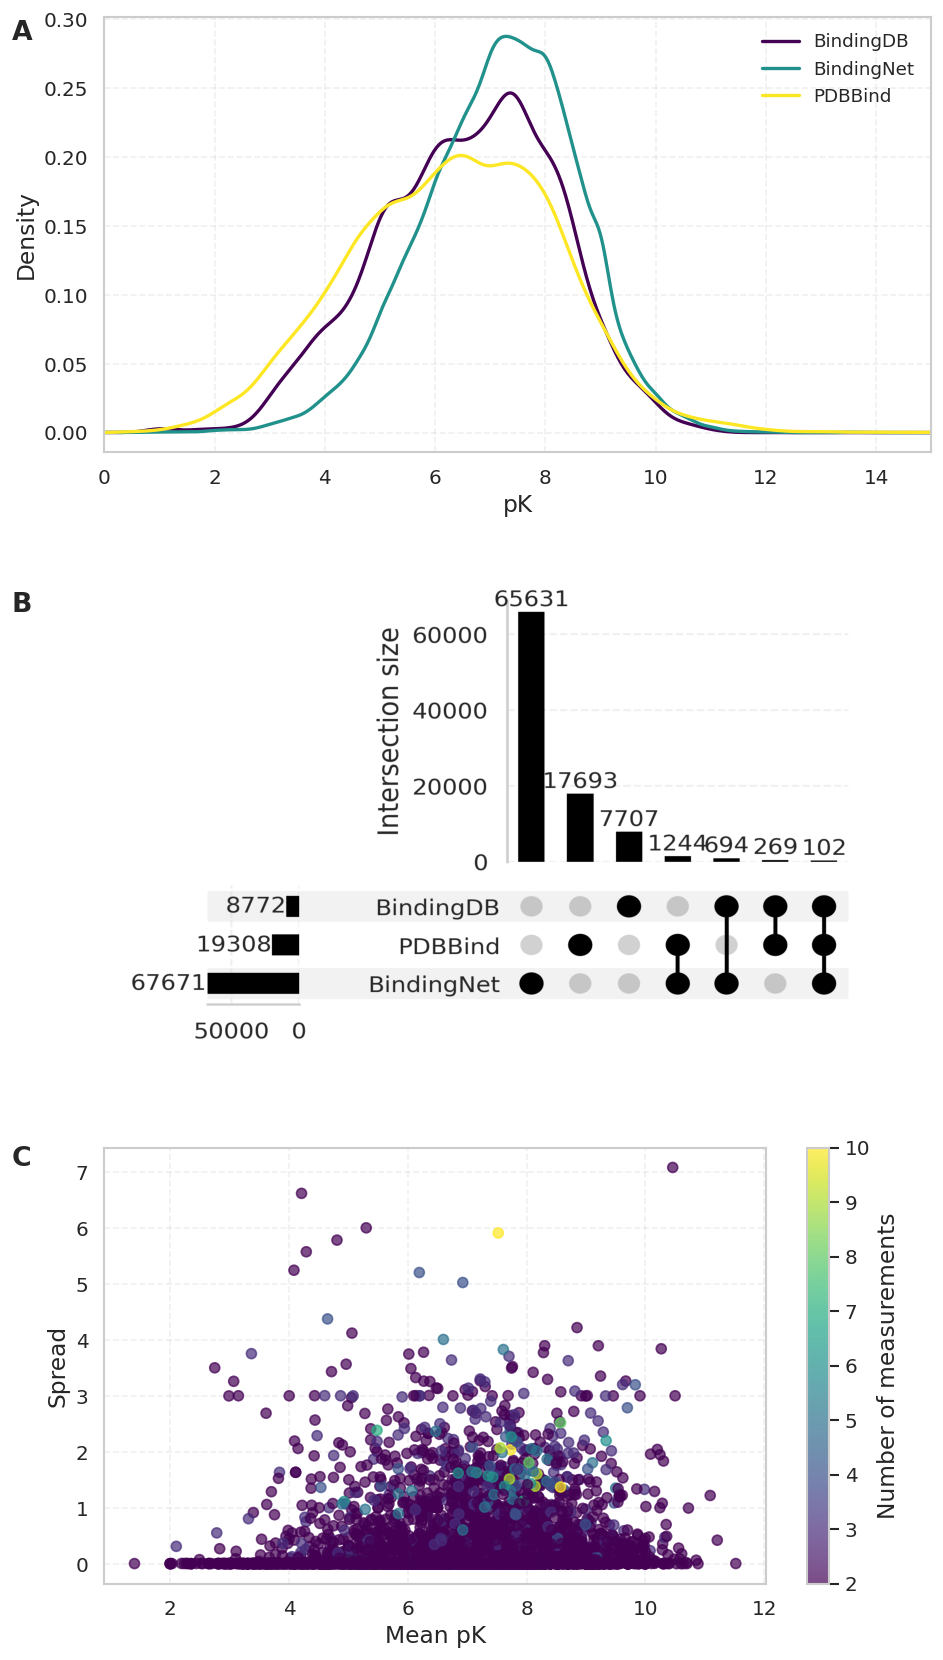

In [29]:
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt

datasets = {
    "BindingDB": set(df[df["source"] == "BindingDB"]["pair"]),
    "BindingNet": set(df[df["source"] == "BindingNet"]["pair"]),
    "PDBBind": set(df[df["source"] == "PDBBind"]["pair"]),
}
#datasets = {
#    "BindingDB": set(df[df["source"] == "bindingdb"]["pair"]),
#    "BindingNet": set(df[df["source"] == "bindingnet"]["pair"]),
#    "PDBBind": set(df[df["source"] == "pdbbind"]["pair"]),
#    "CASF2016": set(df[df["source"] == "casf2016"]["pair"]),
#    "LigandBias0": set(df[df["source"] == "0ligandbias"]["pair"]),
#    "OODTest": set(df[df["source"] == "oodtest"]["pair"]),
#    "FEP": set(df[df["source"] == "fep"]["pair"]),
#}

upset_data = from_contents(datasets)

fig_upset = plt.figure(figsize=(6, 4))

up = UpSet(
    upset_data,
    subset_size='count',
    show_counts=True,
    sort_by='cardinality'
)

up.plot(fig=fig_upset)

plt.tight_layout()
plt.savefig(f"{image_dir}upset_panel.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()

import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig = plt.figure(figsize=(8, 14))
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1.2, 1])

# Assume your sources are:
sources = ["BindingDB", "BindingNet", "PDBBind"]

# Choose 3 positions evenly spaced from 0 to 1 in the colormap
colors = cm.viridis(np.linspace(0, 1, len(sources)))

ax1 = fig.add_subplot(gs[0])

for color, source in zip(colors, sources):
    group = df[df["source"] == source]
    group["pK"].plot(kind="kde", ax=ax1, label=source, linewidth=2, color=color)

ax1.set_xlabel("pK")
ax1.set_ylabel("Density")
#ax1.set_title("Distribution of binding affinities")
ax1.set_xlim([0,15])
ax1.legend(frameon=False)



# Panel 2 (image!)
ax2 = fig.add_subplot(gs[1])
img = mpimg.imread(f"{image_dir}/upset_panel.png")
ax2.imshow(img)
ax2.axis("off")
ax2.set_aspect("auto")

# Panel 3
ax3 = fig.add_subplot(gs[2])

pair_stats = df.groupby("pair")["pK"].agg(["min", "max", "mean"])
pair_stats["spread"] = np.abs(pair_stats["max"] - pair_stats["min"])
pair_stats["count"] = df.groupby("pair").size()

pair_stats_multi = pair_stats[pair_stats["count"] > 1]

sc = ax3.scatter(
    pair_stats_multi["mean"],
    pair_stats_multi["spread"],
    c=pair_stats_multi["count"],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(sc, ax=ax3, label="Number of measurements")

ax3.set_xlabel("Mean pK")
ax3.set_ylabel("Spread")
#ax3.set_yscale("log")

fig.text(0.02, 0.97, "A", fontsize=16, fontweight="bold")
fig.text(0.02, 0.63, "B", fontsize=16, fontweight="bold")
fig.text(0.02, 0.30, "C", fontsize=16, fontweight="bold")

# Final layout
plt.tight_layout()
plt.savefig(f"{image_dir}/data_analysis.png", dpi=300)
plt.show()